Different modules

In [118]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import os
from collections import defaultdict

First we are going to get the data from our scraping, which is in data_reddit_query, and then put it into a dataframe.

In [91]:
path = "data_reddit_query"
dfs = []
for filename in os.listdir(path):
    with open(os.path.join(path, filename), "r", encoding="utf-8") as file:
        data = json.load(file)
        try:
            data = data["data"]
            data = data["children"]
            df = pd.json_normalize(data)
            dfs.append(df)
        except:
            pass

df = pd.concat(dfs, ignore_index=True)
    

C:\Users\piets\AppData\Local\Temp\ipykernel_4984\1304277510.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True)


Removing potential duplicates, this can be done due to all reddit posts URL is unique

In [93]:
df = df.drop_duplicates(subset=['data.permalink'])

In [94]:
df

,kind,data.approved_at_utc,data.subreddit,data.selftext,data.author_fullname,data.saved,data.mod_reason_title,data.gilded,data.clicked,data.title,...,data.media_metadata.tst1y703ldjf1.s.u,data.media_metadata.tst1y703ldjf1.id,data.media_metadata.by1qca92ldjf1.status,data.media_metadata.by1qca92ldjf1.e,data.media_metadata.by1qca92ldjf1.m,data.media_metadata.by1qca92ldjf1.p,data.media_metadata.by1qca92ldjf1.s.y,data.media_metadata.by1qca92ldjf1.s.x,data.media_metadata.by1qca92ldjf1.s.u,data.media_metadata.by1qca92ldjf1.id
0,t3,None,Denmark,Hej\n\nInspireret af [denne tråd](https://www....,t2_lbdcp,False,None,0.0,False,Chat Control mail til supportere / uafklarede ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,t3,None,Denmark,Der bliver skrevet en hel masse om chat-contro...,t2_1ya5046t6j,False,None,0.0,False,"PET-lov, chat-control og aldersverifikation",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,t3,None,Denmark,Jeg har set nogle tråde rundt om på Reddit om ...,t2_5d48e,False,None,0.0,False,ChatControl er måske allerede implementeret. D...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,t3,None,Denmark,📢 På søndag kl. 14 er der demonstration mod Ch...,t2_1fa3wb0wr0,False,None,0.0,False,Demonstration mod Chat Control – søndag kl. 14...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,t3,None,Denmark,Tyskland er igen blevet ubeslutsom. Fortsæt ve...,t2_5g2jc9ml,False,None,0.0,False,"Til dem, der er bekymrede over ChatControl:",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,t3,None,Denmark,[Rigspolitiet udpeger 35 kriminelle familier i...,t2_5d48e,False,None,0.0,False,35 familier udpeget som kriminelle,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
927,t3,None,Denmark,(Artiklen er bag betalingsmur) Over 600 forske...,t2_ajckf99c,False,None,0.0,False,Chatkontrol” skal redde børn – hvorfor bekymre...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
928,t3,None,Denmark,,t2_1vpwsrm6g6,False,None,0.0,False,Støjberg er ikke den eneste - flere politikere...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
930,t3,None,Denmark,,t2_7rk28,False,None,0.0,False,Justitsminister [Peter Hummelgaard (S)] lufter...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
df = df.astype({'data.selftext': str, 'data.subreddit': str, 'data.title': str})

In [105]:
df.dtypes

kind                                      object
data.approved_at_utc                      object
data.subreddit                            object
data.selftext                             object
data.author_fullname                      object
                                          ...   
data.media_metadata.by1qca92ldjf1.p       object
data.media_metadata.by1qca92ldjf1.s.y    float64
data.media_metadata.by1qca92ldjf1.s.x    float64
data.media_metadata.by1qca92ldjf1.s.u     object
data.media_metadata.by1qca92ldjf1.id      object
Length: 907, dtype: object

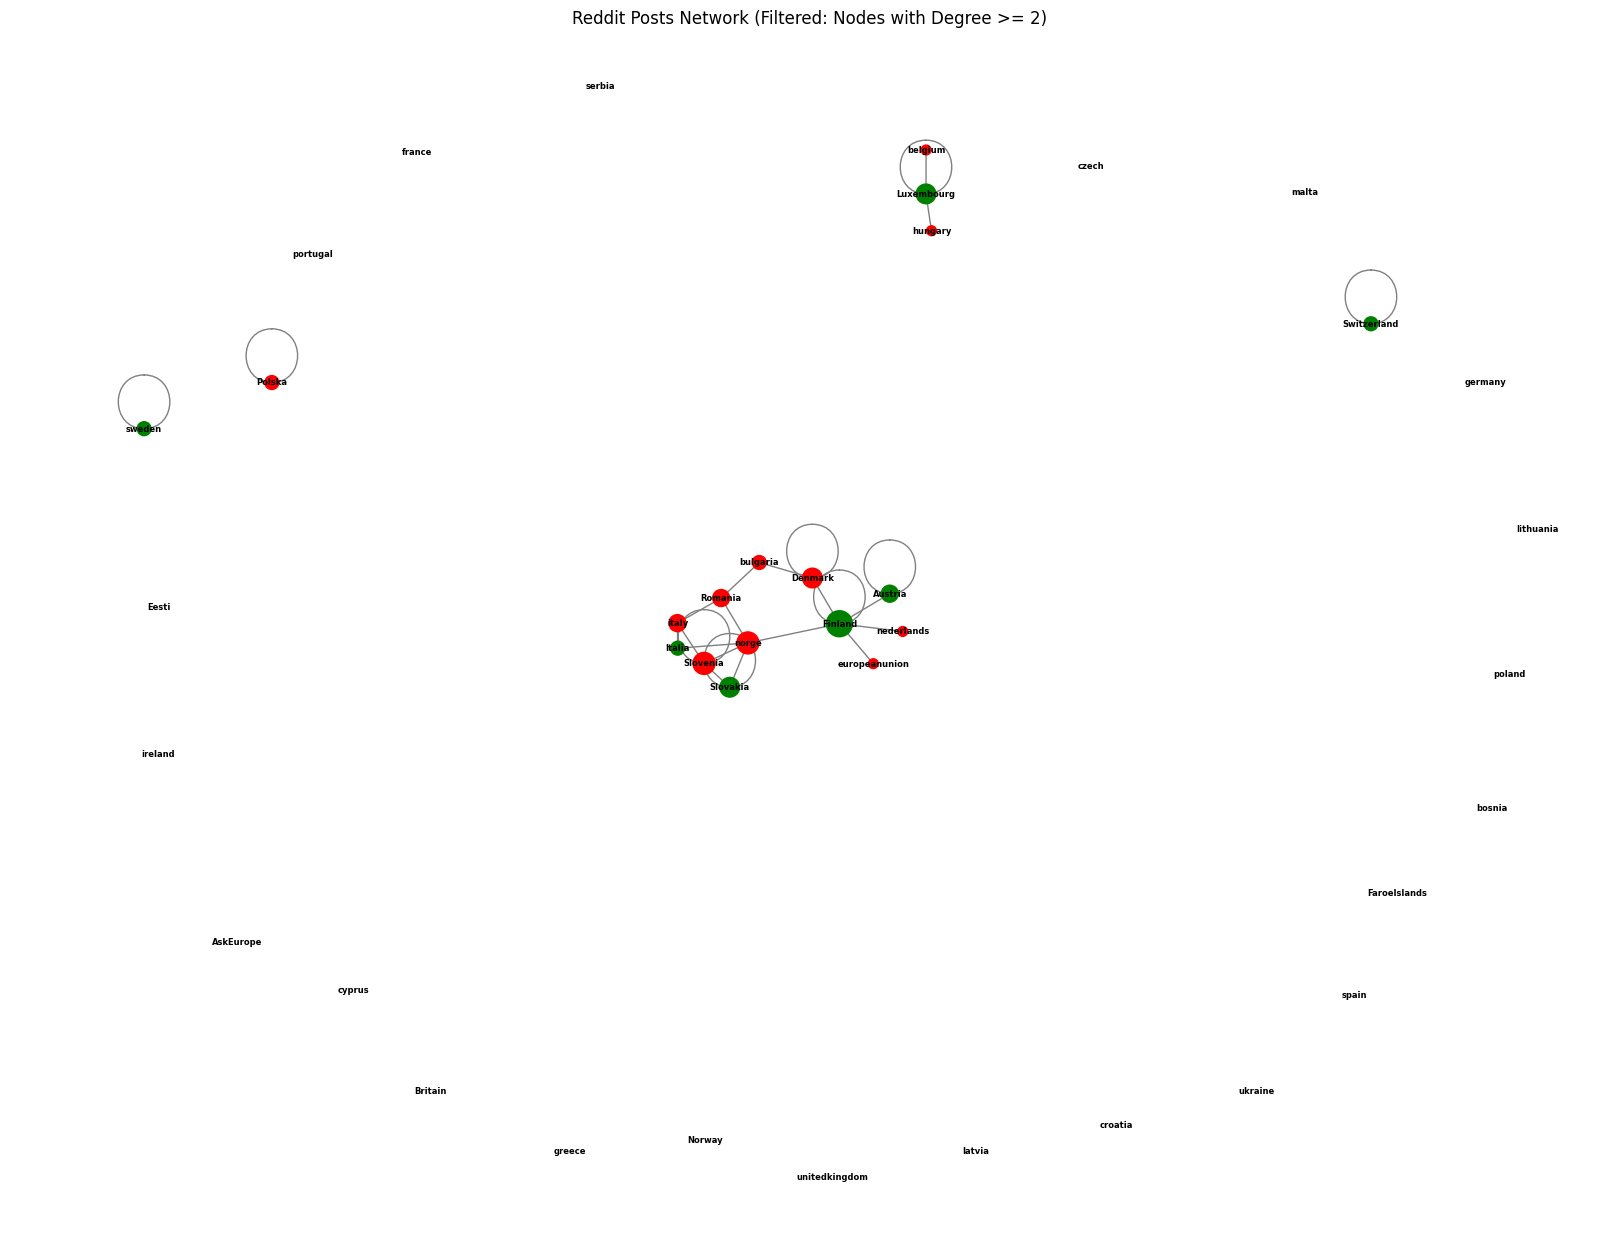

In [132]:

G = nx.Graph()

for _, row in df.iterrows():
    subreddit = row["data.subreddit"]
    title = row["data.title"]
    body = row["data.selftext"]

    if not (subreddit and body and title):
        continue  # skip incomplete entries


    G.add_node(subreddit, type="subreddit")


    # Split title into words and add each as a node
    words = body.split()  # Split by whitespace
    for word in words:
        G.add_node(word, type="word")
        G.add_edge(word, subreddit)  # word belongs to subreddit

# Remove nodes with degree less than 2
degrees = dict(G.degree())
nodes_to_remove = [
    node for node, attrs in G.nodes(data=True)
    if attrs.get("type") == "word" and degrees[node] < 50
]
G.remove_nodes_from(nodes_to_remove)

# Calculate node sizes based on degree (number of connections)
degrees = dict(G.degree())
node_sizes = [degrees[node] * 50 for node in G.nodes()]  # Scale for visibility

# Draw network
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42)

# Color nodes by type
colors = []
for node, attrs in G.nodes(data=True):
    if attrs["type"] == "subreddit":
        colors.append("red")
    else:
        colors.append("green")  # words

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=node_sizes,  # Use calculated sizes
    font_size=6,
    font_weight="bold",
    edge_color="gray"
)

plt.title("Reddit Posts Network (Filtered: Nodes with Degree >= 2)")
plt.show()
